# Day 2 — Can we trust our experiment?

Before measuring whether the redesign works, we need to know whether the two
groups can fairly be compared at all. If Control and Test started out with
different kinds of clients, any difference we find later could be about who
they are rather than what they saw.

Two questions, in this order: who are Vanguard's clients, and are the two
groups alike?

## Setup

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from project_template.paths import PROCESSED_DIR
from project_template.config import CONFIG

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

# Vanguard's palette, so charts match the deck
MAROON, NAVY = "#96151D", "#21384E"
PALETTE = {"Control": NAVY, "Test": MAROON}

ALPHA = CONFIG["statistics"]["alpha"]
ALPHA

0.05

In [2]:
clients = pd.read_parquet(PROCESSED_DIR / "clients.parquet")

print(f"{len(clients):,} clients")
print(clients.Variation.value_counts().to_string())
clients.head()

50,488 clients
Variation
Test       26961
Control    23527


,client_id,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,8320017,Test,22.0,274.0,34.5,M,2.0,36001.90,5.0,8.0
2,4033851,Control,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0
3,1982004,Test,6.0,80.0,44.5,U,2.0,30231.76,1.0,4.0
4,9294070,Control,5.0,70.0,29.0,U,2.0,34254.54,0.0,3.0


## 1. Who are Vanguard's clients?

Before comparing the groups, understand the population they were drawn from.
Vanguard's own reporting describes a client base concentrated in retirement
saving, so we should expect long tenures and balances that rise with age.

In [3]:
NUMERIC = ["clnt_age", "clnt_tenure_yr", "bal", "num_accts",
           "calls_6_mnth", "logons_6_mnth"]

clients[NUMERIC].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
clnt_age,50487.0,47.3,15.5,17.0,33.5,48.0,59.5,96.0
clnt_tenure_yr,50488.0,12.0,6.9,2.0,6.0,11.0,16.0,55.0
bal,50488.0,149514.7,302036.4,23789.4,39878.4,65733.6,139956.5,16320040.2
num_accts,50488.0,2.3,0.5,1.0,2.0,2.0,2.0,7.0
calls_6_mnth,50488.0,3.1,2.2,0.0,1.0,3.0,5.0,6.0
logons_6_mnth,50488.0,6.1,2.2,3.0,4.0,6.0,8.0,9.0


Means and medians tell different stories when a distribution is skewed, and
`bal` is the obvious candidate. Comparing the two says how skewed each variable
is, and therefore which summary is honest to quote.

In [4]:
summary = pd.DataFrame({
    "mean": clients[NUMERIC].mean(),
    "median": clients[NUMERIC].median(),
    "skew": clients[NUMERIC].skew(),
}).round(2)
summary["mean / median"] = (summary["mean"] / summary["median"]).round(2)
summary

,mean,median,skew,mean / median
clnt_age,47.32,48.0,0.08,0.99
clnt_tenure_yr,12.03,11.0,1.03,1.09
bal,149514.68,65733.6,11.47,2.27
num_accts,2.25,2.0,2.29,1.12
calls_6_mnth,3.09,3.0,0.05,1.03
logons_6_mnth,6.13,6.0,0.03,1.02


### The shape of each variable

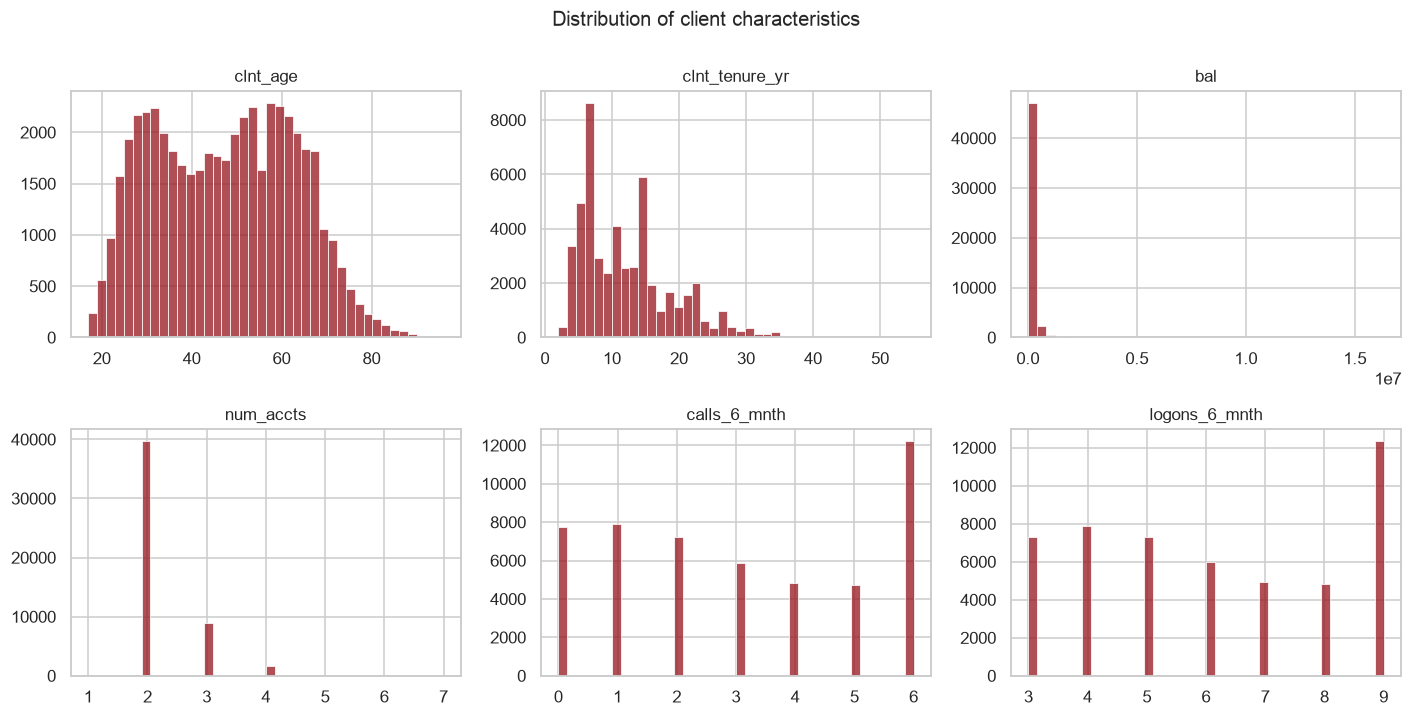

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))

for ax, col in zip(axes.flat, NUMERIC):
    sns.histplot(clients[col].dropna(), bins=40, ax=ax, color=MAROON, alpha=.75)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Distribution of client characteristics", fontsize=13, y=1.0)
fig.tight_layout()
plt.show()

### Does wealth rise with age, as Vanguard's own reporting suggests?

In [6]:
profile = clients.dropna(subset=["clnt_age"]).copy()
profile["age_band"] = pd.cut(
    profile.clnt_age, [0, 35, 50, 65, 120],
    labels=["<35", "35-50", "50-65", "65+"],
)

by_band = profile.groupby("age_band", observed=True).agg(
    clients=("client_id", "size"),
    median_balance=("bal", "median"),
    median_tenure=("clnt_tenure_yr", "median"),
    mean_logons=("logons_6_mnth", "mean"),
    mean_calls=("calls_6_mnth", "mean"),
).round(1)
by_band

,clients,median_balance,median_tenure,mean_logons,mean_calls
age_band,,,,,
<35,14328,47490.5,7.0,6.1,3.1
35-50,13028,66386.2,12.0,5.9,2.8
50-65,16148,84136.3,12.0,6.2,3.1
65+,6983,115365.1,14.0,6.5,3.4


### Unusual observations

Not everything odd is an error, but everything odd needs explaining. Three
things to check: values that are impossible, values that contradict each
other, and distributions that look shaped by the recording process rather
than by client behaviour.

In [7]:
checks = {
    "age below 18": (clients.clnt_age < 18).sum(),
    "tenure longer than the client's age": (clients.clnt_tenure_yr > clients.clnt_age).sum(),
    "tenure in years inconsistent with tenure in months":
        ((clients.clnt_tenure_mnth // 12) != clients.clnt_tenure_yr).sum(),
    "balance zero or negative": (clients.bal <= 0).sum(),
    "never logged on in six months": (clients.logons_6_mnth == 0).sum(),
}

for label, n in checks.items():
    print(f"{label:52} {n:>6,}")

print()
print(f"age      {clients.clnt_age.min():>10,.0f}  to {clients.clnt_age.max():>12,.0f}")
print(f"balance  {clients.bal.min():>10,.0f}  to {clients.bal.max():>12,.0f}")

age below 18                                             62
tenure longer than the client's age                     331
tenure in years inconsistent with tenure in months       31
balance zero or negative                                  0
never logged on in six months                             0

age              17  to           96
balance      23,789  to   16,320,040


A client cannot have been with Vanguard longer than they have been alive.
Worth looking at directly rather than assuming a rounding artefact.

In [8]:
impossible = clients[clients.clnt_tenure_yr > clients.clnt_age]

print(f"{len(impossible)} clients, "
      f"{len(impossible) / len(clients):.2%} of the file")
impossible[["client_id", "clnt_age", "clnt_tenure_yr", "bal"]].head(8)

331 clients, 0.66% of the file


,client_id,clnt_age,clnt_tenure_yr,bal
249,9707270,18.0,23.0,71178.73
565,3025507,45.0,48.0,104398.94
653,495241,20.5,21.0,29291.43
671,8225520,28.5,33.0,115702.56
784,2459641,21.0,24.0,34736.92
1220,2304952,26.0,28.0,35774.62
1272,1865475,21.0,23.0,46289.11
1457,9006692,19.0,21.0,35431.82


The engagement variables deserve a second look. Their ranges are suspiciously
narrow for counts that should in principle be unbounded.

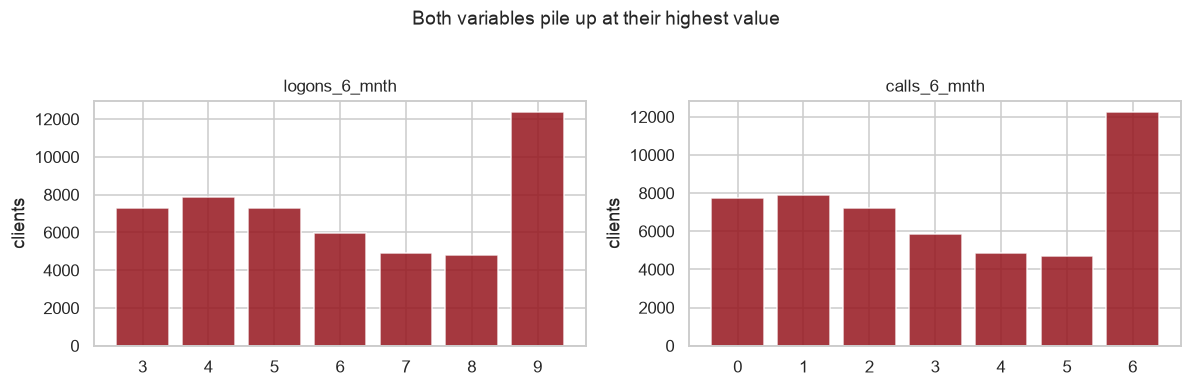

     logons_6_mnth  calls_6_mnth
min            3.0           0.0
max            9.0           6.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

for ax, col in zip(axes, ["logons_6_mnth", "calls_6_mnth"]):
    counts = clients[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=MAROON, alpha=.85)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("clients")

fig.suptitle("Both variables pile up at their highest value", fontsize=12.5, y=1.03)
fig.tight_layout()
plt.show()

print(clients[["logons_6_mnth", "calls_6_mnth"]].agg(["min", "max"]).to_string())

Neither is a natural distribution. `logons_6_mnth` never falls below 3 and
never exceeds 9, and `calls_6_mnth` stops at 6 — with a large pile of clients
sitting exactly on each maximum. These variables are **top-coded**: values
above the cap were recorded as the cap rather than as their true value.

That does not make them unusable, but it does mean their means understate the
real spread, and that any later analysis treating them as ordinary counts
would be misleading.

**Question to answer:** who are Vanguard's clients, and are there segments
worth carrying into the rest of the analysis?

## 2. Are the two groups alike?

The groups are different sizes, so raw counts cannot be compared directly.
Everything below uses proportions or densities.

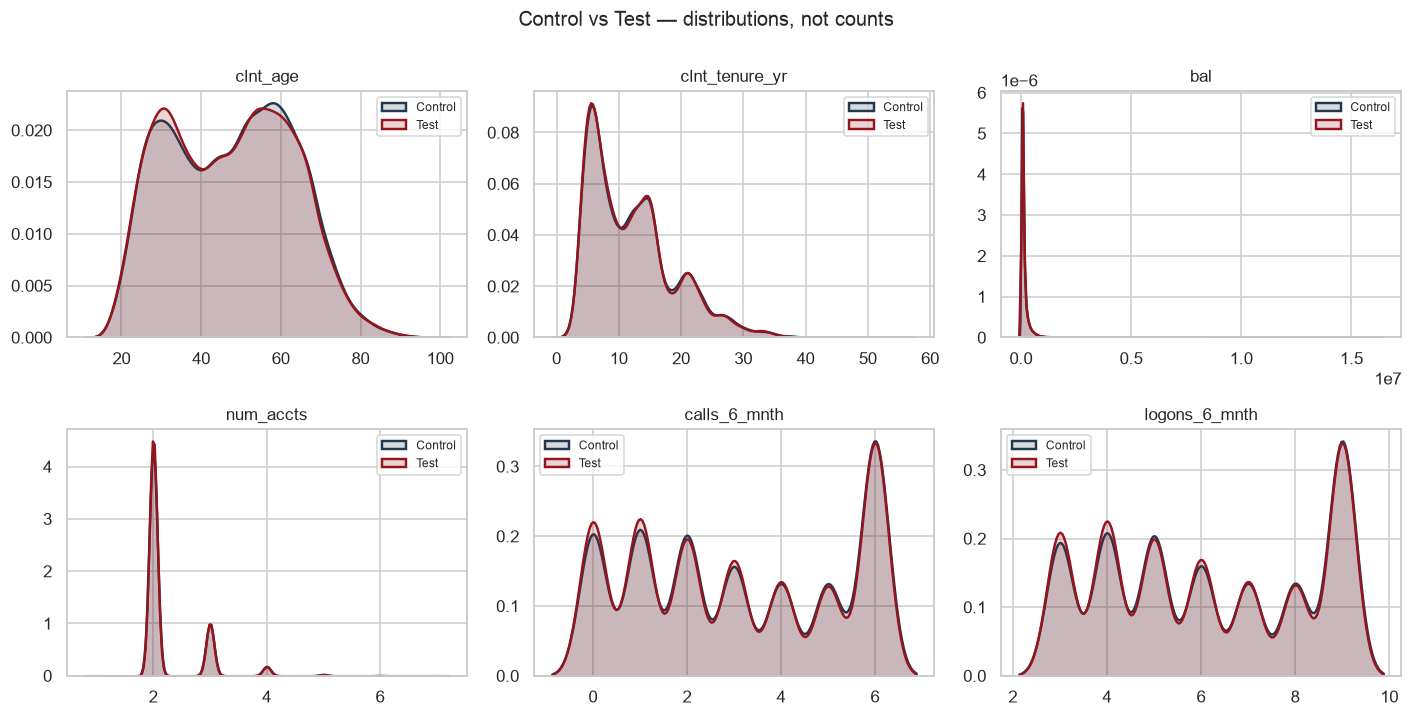

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))

for ax, col in zip(axes.flat, NUMERIC):
    for group, colour in PALETTE.items():
        sns.kdeplot(
            clients.loc[clients.Variation == group, col].dropna(),
            ax=ax, label=group, color=colour, fill=True, alpha=.18, linewidth=1.6,
        )
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.legend(fontsize=8)

fig.suptitle("Control vs Test — distributions, not counts", fontsize=13, y=1.0)
fig.tight_layout()
plt.show()

In [11]:
gender = pd.crosstab(clients.gendr, clients.Variation, normalize="columns") * 100
gender.round(2)

Variation,Control,Test
gendr,,
F,32.06,32.33
M,33.88,33.30
U,34.06,34.37
X,0.00,0.01


### Centre, spread and shape

The density plots show the shape and the medians show the centre. Spread is
the third thing that can differ, and two groups can share a median while
being distributed very differently around it.

Levene's test compares variances. Centring it on the median rather than the
mean makes it robust to the skew we already know is there.

In [12]:
spread = []

for col in NUMERIC:
    control = clients.loc[clients.Variation == "Control", col].dropna()
    test = clients.loc[clients.Variation == "Test", col].dropna()
    iqr = lambda s: s.quantile(.75) - s.quantile(.25)

    spread.append({
        "variable": col,
        "sd Control": round(control.std(), 1),
        "sd Test": round(test.std(), 1),
        "IQR Control": round(iqr(control), 1),
        "IQR Test": round(iqr(test), 1),
        "Levene p": round(stats.levene(control, test, center="median").pvalue, 3),
    })

spread = pd.DataFrame(spread)
spread["equal spread"] = np.where(spread["Levene p"] > ALPHA, "yes", "no")
spread

,variable,sd Control,sd Test,IQR Control,IQR Test,Levene p,equal spread
0,clnt_age,15.5,15.5,26.5,26.0,0.839,yes
1,clnt_tenure_yr,6.9,6.8,10.0,9.0,0.370,yes
2,bal,295807.0,307373.7,100482.7,99749.4,0.796,yes
3,num_accts,0.5,0.5,0.0,0.0,0.037,no
4,calls_6_mnth,2.2,2.2,4.0,4.0,0.867,yes
5,logons_6_mnth,2.2,2.2,4.0,4.0,0.871,yes


## 3. Choosing the right test

Two things decide which test is appropriate: the type of variable, and whether
the assumptions hold.

The distributions above are visibly skewed, so the mean is not a fair summary
of a typical client. With roughly 25,000 clients per group the Central Limit
Theorem would still make a t-test valid for comparing means — but the question
is whether *typical* clients differ, not whether the averages do. That points
to a rank-based test.

Formal normality tests are not useful at this sample size: with n this large
they reject essentially any real-world distribution, so they would tell us
nothing we did not already see in the plots.

In [13]:
for col in NUMERIC:
    s = clients[col].dropna()
    print(f"{col:16} skew {s.skew():>7.2f}   kurtosis {s.kurtosis():>8.2f}")

clnt_age         skew    0.08   kurtosis    -0.95
clnt_tenure_yr   skew    1.03   kurtosis     1.02
bal              skew   11.47   kurtosis   294.12
num_accts        skew    2.29   kurtosis     6.00
calls_6_mnth     skew    0.05   kurtosis    -1.44
logons_6_mnth    skew    0.03   kurtosis    -1.43


So: **Mann-Whitney U** for the numeric variables, comparing distributions
rather than means, and **chi-square** for gender.

A p-value alone is not enough. With this sample size a difference of no
practical consequence will still come out significant, so every test is
reported with an effect size:

- **rank-biserial correlation** for Mann-Whitney, which runs from -1 to 1 and
  is roughly 0.1 for a small effect
- **Cramér's V** for chi-square, on the same kind of scale

In [14]:
def rank_biserial(a, b):
    """Effect size for Mann-Whitney: 0 means the groups are interchangeable."""
    u, _ = stats.mannwhitneyu(a, b, alternative="two-sided")
    return 1 - 2 * u / (len(a) * len(b))


def cramers_v(table):
    chi2 = stats.chi2_contingency(table).statistic
    n = table.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))

## 4. The comparison

Every variable, with the median in each group, the p-value, and the effect
size side by side.

In [15]:
rows = []

for col in NUMERIC:
    control = clients.loc[clients.Variation == "Control", col].dropna()
    test = clients.loc[clients.Variation == "Test", col].dropna()
    u, p = stats.mannwhitneyu(control, test, alternative="two-sided")
    rows.append({
        "variable": col,
        "median Control": round(control.median(), 1),
        "median Test": round(test.median(), 1),
        "test": "Mann-Whitney",
        "p-value": p,
        "effect size": round(rank_biserial(control, test), 4),
    })

gender_table = pd.crosstab(clients.gendr, clients.Variation)
rows.append({
    "variable": "gendr",
    "median Control": np.nan,
    "median Test": np.nan,
    "test": "chi-square",
    "p-value": stats.chi2_contingency(gender_table).pvalue,
    "effect size": round(cramers_v(gender_table), 4),
})

comparison = pd.DataFrame(rows)
comparison["significant"] = np.where(comparison["p-value"] < ALPHA, "yes", "no")
comparison["p-value"] = comparison["p-value"].map(lambda x: f"{x:.2e}")
comparison

,variable,median Control,median Test,test,p-value,effect size,significant
0,clnt_age,48.5,47.5,Mann-Whitney,1.47e-02,-0.0126,yes
1,clnt_tenure_yr,11.0,11.0,Mann-Whitney,8.69e-02,-0.0088,no
2,bal,66024.2,65468.4,Mann-Whitney,1.49e-01,-0.0074,no
3,num_accts,2.0,2.0,Mann-Whitney,3.02e-02,-0.0080,yes
4,calls_6_mnth,3.0,3.0,Mann-Whitney,5.01e-04,-0.0177,yes
5,logons_6_mnth,6.0,6.0,Mann-Whitney,8.37e-04,-0.0170,yes
6,gendr,NaN,NaN,chi-square,3.05e-01,0.0085,no


Read the last two columns together rather than one at a time. That contrast is
the whole point of this table.

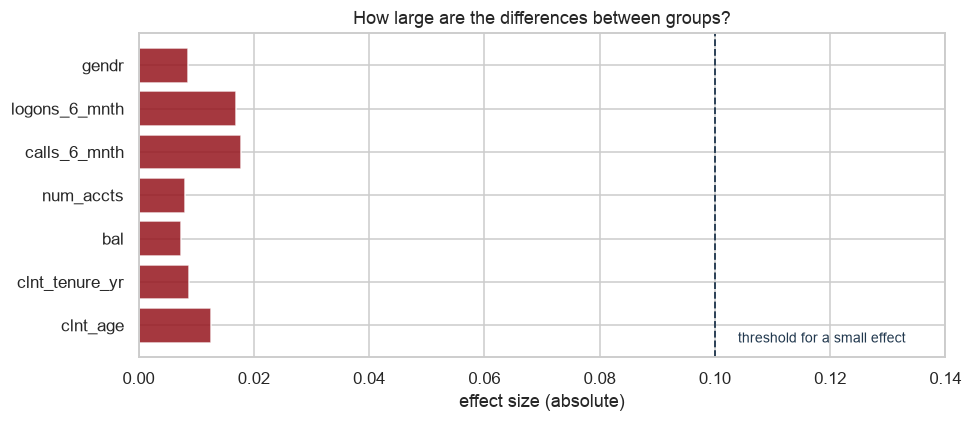

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))

sizes = comparison["effect size"].abs()
ax.barh(comparison.variable, sizes, color=MAROON, alpha=.85)
ax.axvline(0.1, color=NAVY, linestyle="--", linewidth=1.2)
ax.text(0.104, -0.4, "threshold for a small effect", color=NAVY, fontsize=9)
ax.set_xlim(0, max(0.14, sizes.max() * 1.25))
ax.set_xlabel("effect size (absolute)")
ax.set_title("How large are the differences between groups?", fontsize=12)
fig.tight_layout()
plt.show()

**Question to answer:** which of these differences, if any, would meaningfully
affect the experiment?

## 5. Threats to validity

Day 1 established that the assignment itself is uneven: 53.4% of clients went
to Test against 46.6% to Control, far beyond what chance explains. It also
established that the imbalance is unrelated to age (p = 0.11).

That check covered one variable. The same question applies to the rest.

In [17]:
threats = []

for col in NUMERIC:
    control = clients.loc[clients.Variation == "Control", col].dropna()
    test = clients.loc[clients.Variation == "Test", col].dropna()
    threats.append({
        "variable": col,
        "effect size": abs(rank_biserial(control, test)),
    })

threats = pd.DataFrame(threats).sort_values("effect size", ascending=False)
threats["reading"] = np.where(
    threats["effect size"] < 0.1, "negligible", "worth investigating"
)
threats.round(4)

,variable,effect size,reading
4,calls_6_mnth,0.0177,negligible
5,logons_6_mnth,0.0170,negligible
0,clnt_age,0.0126,negligible
1,clnt_tenure_yr,0.0088,negligible
3,num_accts,0.0080,negligible
2,bal,0.0074,negligible


## Conclusions

### Who Vanguard's clients are

A long-tenured, middle-aged client base: median age 48, median tenure 11
years, median balance around $66,000. That matches what Vanguard reports
publicly about itself — a company built on retirement saving rather than
active trading.

Wealth accumulates with age, steeply. Median balance runs from roughly
$47,000 in the under-35s to $115,000 in clients aged 65 and over, while
tenure doubles across the same range. Balance is the most skewed variable in
the file by a wide margin — the mean sits far above the median and the
maximum exceeds $16 million — so the median is the only honest summary of a
typical client.

Three observations we are carrying forward rather than cleaning away:

- **331 clients have been with Vanguard longer than they have been alive**,
  which is impossible. They are 0.66% of the file. Small enough not to move
  any aggregate, but it means the demographic fields carry some recording
  error, and it is worth knowing before any conclusion rests on tenure.
- **`logons_6_mnth` and `calls_6_mnth` are top-coded.** Logons never fall
  below 3 or exceed 9, calls stop at 6, and both pile up at their maximum.
  Their means understate the true spread, and neither should be treated as an
  ordinary count.
- **62 clients are under 18.** Plausible for custodial accounts, so recorded
  rather than removed.

### Whether the groups are comparable

| Variable | Statistically significant? | Effect size | Does it matter? |
|---|---|---|---|
| clnt_age | yes (p = 0.015) | −0.013 | No. Medians differ by one year |
| clnt_tenure_yr | no (p = 0.087) | −0.009 | No |
| bal | no (p = 0.149) | −0.007 | No |
| num_accts | yes (p = 0.030) | −0.008 | No. Both groups have a median of 2 |
| calls_6_mnth | yes (p = 0.0005) | −0.018 | No. Identical medians |
| logons_6_mnth | yes (p = 0.0008) | −0.017 | No. Identical medians |
| gendr | no (p = 0.305) | 0.009 | No |

Four of the seven variables are statistically significant, and **not one of
them matters**. Every effect size falls below 0.02, against a conventional
threshold of 0.1 for an effect worth calling small. The medians are identical
or differ by a single unit.

`calls_6_mnth` is the clearest illustration: p = 0.0005 looks like a finding
until the effect size, 0.018, says the two groups are practically
interchangeable. With about 25,000 clients per arm, the tests are powerful
enough to detect differences far too small to matter.

Spread agrees with centre. Standard deviations and interquartile ranges are
near-identical across groups, and Levene's test finds no difference for any
variable except `num_accts` — where both groups have an interquartile range
of zero, so the test is registering noise in a variable that is almost
constant.

### Why these methods

**Mann-Whitney rather than a t-test.** Every numeric variable is skewed, most
of them severely. With samples this large the Central Limit Theorem would
make a t-test valid for comparing means, but the mean is not a fair
description of a typical client when balance runs to $16 million. Mann-Whitney
compares distributions and answers the question we actually have: do typical
clients differ?

**Chi-square for gender**, the standard test for association between two
categorical variables, with `U` kept as its own category — it means "not
reported", and dropping a third of the sample would bias the comparison it is
meant to test.

**No normality tests.** At n ≈ 25,000 they reject essentially any real-world
distribution, so a rejection would tell us nothing the histograms had not
already shown. Skewness, kurtosis and the plots are the honest evidence here.

**An effect size beside every p-value.** At this sample size significance is
close to guaranteed, so a p-value alone cannot answer whether a difference
matters. Reporting both is what makes the table above readable.

### Verdict on the experiment

**The comparison between Control and Test is fair.** No client characteristic
differs by an amount that could plausibly explain a difference in outcomes,
whether measured by centre, spread or shape.

Two qualifications travel with that verdict:

**The assignment is imbalanced.** 53.4% of clients went to Test against 46.6%
to Control, far beyond what chance explains. Day 1 established that the
imbalance is unrelated to age (p = 0.11), and the results above extend that to
every other client characteristic — whatever caused it, it did not sort
clients by who they are. We report it rather than correcting it, because the
cause is not recoverable from the data.

**The analysable population is not the whole client base.** 20,109 clients
were never randomised and 49,548 appear in the log with no profile. Both are
excluded, and the unassigned are measurably younger than those who took part.
Conclusions therefore describe the 50,488 randomised, profiled clients — not
every Vanguard client.

**Final question — is there evidence that would make the comparison unfair?**
No. The groups are alike on everything we can measure. What remains is a
documented imbalance in group sizes with no detectable relationship to client
characteristics, and a clearly stated limit on who the conclusions apply to.